In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Interpolazione polinomiale

**Implementazione del metodo dei coefficienti indeterminati**

Date le coppie di punti $(x_i,y_i)$, $i=0,...,n$, si vuole determinare l'unico polinomio di grado $n$ al cui grafico appartengono i punti dati.

Formula di un polinomio di grado $n$ in forma canonica:
$$p_n(x) = a_1+a_1x + a_2x^2+...+a_nx^n $$
Condizioni di interpolazione:
$$p_n(x_i) = y_i, \ \ i=0,...,n$$

Mettendo insieme le due formule si ottengono le seguenti uguaglianze

$$
\left\{
\begin{array}{lcl}
a_0 + a_1x_0 + a_2x_0^2+...+a_nx_0^n &=& y_0\\
a_0 + a_1x_1 + a_2x_1^2+...+a_nx_1^n &=& y_1\\
 & \vdots\\
a_0 + a_1x_n + a_2x_n^2+...+a_nx_n^n &=& y_n\\
\end{array}
\right.
$$
che vanno interpretate come un sistema lineare di $n+1$ equazioni nelle $n+1$ incognite $a_0,a_1,a_2,...,a_n$.

La forma matriciale del sistema è la seguente
$$ V\alpha = y$$
dove
$$V= \left(\begin{array}{cccc}
1 & x_0 & {x_0}^2  & \dots  & {x_0}^n \\
1 & x_1 & {x_1}^2  & \dots  & {x_1}^n \\
\vdots  & \vdots & \vdots &  & \vdots \\
1&x_n   & {x_n}^2  & \dots  & {x_n}^n
\end{array}\right), \qquad \alpha = \begin{pmatrix}a_0\\a_1\\ \vdots\\a_n\end{pmatrix},\ y = \begin{pmatrix}y_0\\y_1\\ \vdots\\y_n\end{pmatrix}$$

Il coefficienti dell'unico polinomio di interpolazione si ottengono quindi risolvendo il sistema qui sopra.



In [4]:
def pol_interp(x, y):
    """
    Costruzione del polinomio interpolante tramite matrice di Vandermonde.

    INPUT:
    - x : array numpy con le ascisse dei punti (n punti)
    - y : array numpy con le ordinate dei punti

    OUTPUT:
    - a : array numpy dei coefficienti del polinomio interpolante
          nella forma:
          p(x) = a[0] + a[1]x + ... + a[n-1]x^(n-1)

    IDEA:
    Costruiamo la matrice di Vandermonde V tale che:
        V * a = y
    e risolviamo il sistema lineare per trovare i coefficienti a.
    """

    # Numero di punti (e quindi grado massimo + 1)
    n = x.size

    # Inizializziamo la matrice di Vandermonde con tutti 1
    V = np.ones((n, n))

    # Costruiamo le colonne successive: colonna i = x^i
    # sfruttiamo la relazione: x^i = x^(i-1) * x
    # prima colonna di tutti uni => parto dalla seconda colonna (indice 1)
    for i in range(1, n):
        V[:, i] = V[:, i - 1] * x

    # Risolviamo il sistema lineare V * a = y
    # ottenendo i coefficienti del polinomio
    return np.linalg.solve(V, y)

### Esempio

Creiamo il grafico del polinomio di interpolazione rispetto ai punti dati nell'esempio seguente

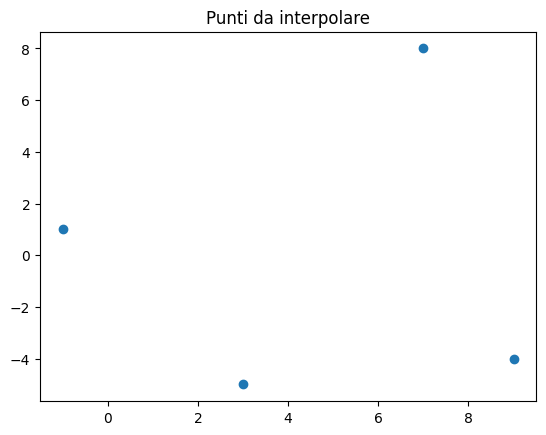

In [5]:
# =======================
# DATI DI INTERPOLAZIONE
# =======================

x = np.array([-1, 3, 7, 9])
y = np.array([1, -5, 8, -4])

# Visualizziamo i punti dati
plt.scatter(x, y)
plt.title("Punti da interpolare")
plt.show()

In [6]:
# =======================
# CALCOLO POLINOMIO
# =======================

# Calcoliamo i coefficienti del polinomio interpolante
a = pol_interp(x, y)

# Stampiamo i coefficienti:
# a[0] + a[1]x + a[2]x^2 + ...
print("Coefficienti del polinomio:", a)

Coefficienti del polinomio: [-6.765625   -5.03645833  2.515625   -0.21354167]


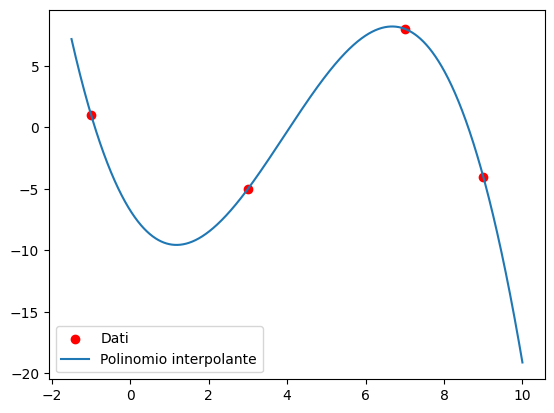

In [10]:
# =======================
# GRAFICO DEL POLINOMIO
# =======================

# Creiamo molti punti per disegnare una curva liscia
xx = np.linspace(-1.5, 10, num=2000)

# np.polyval vuole i coefficienti in ordine decrescente:
# [a_n, ..., a_1, a_0]
# quindi invertiamo il vettore a
yy = np.polyval(a[::-1], xx)

# Disegniamo punti + polinomio interpolante
plt.scatter(x, y, color='red', label="Dati")
plt.plot(xx, yy, label="Polinomio interpolante")

plt.legend()
plt.show()

La funzione di Numpy che calcola il polinomio di interpolazione è `polyfit`, se usata nel modo seguente (si veda [qui](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) per la descrizione completa)

Coefficienti (ordine decrescente): [-0.21354167  2.515625   -5.03645833 -6.765625  ]


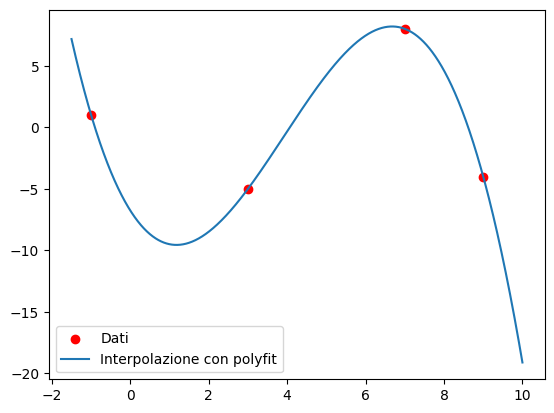

In [11]:
# =======================
# INTERPOLAZIONE CON POLYFIT
# =======================

# np.polyfit costruisce direttamente il polinomio interpolante (o di regressione)
# Restituisce i coefficienti del polinomio in ordine DECRESCENTE:
# p(x) = b[0]*x^n + b[1]*x^(n-1) + ... + b[n]

# Il terzo parametro è il grado del polinomio.
# x.size - 1 --> grado massimo per interpolare esattamente tutti i punti
b = np.polyfit(x, y, x.size - 1)

# =======================
# VALUTAZIONE DEL POLINOMIO
# =======================

# Stampiamo i coefficienti
print("Coefficienti (ordine decrescente):", b)

# np.polyval valuta il polinomio nei punti xx.
# ATTENZIONE: si aspetta i coefficienti in ordine decrescente (come restituiti da polyfit)
zz = np.polyval(b, xx)

# =======================
# GRAFICO
# =======================

# (Opzionale ma utile) mostriamo anche i punti originali
plt.scatter(x, y, color='red', label="Dati")

# Disegniamo il polinomio interpolante
plt.plot(xx, zz, label="Interpolazione con polyfit")

plt.legend()
plt.show()